In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


Ensure plots directory exists

In [3]:
os.makedirs("plots", exist_ok=True)


In [35]:
BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_PATH = os.path.join(BASE_DIR, "data", "co2_data.csv")

Load dataset

In [36]:
df = pd.read_csv(DATA_PATH)


Data Cleaning

In [5]:
df = df.dropna(subset=["co2", "year", "country"])  # remove missing values


### * Plot 1: Global CO2 emissions trend (sum of all countries)

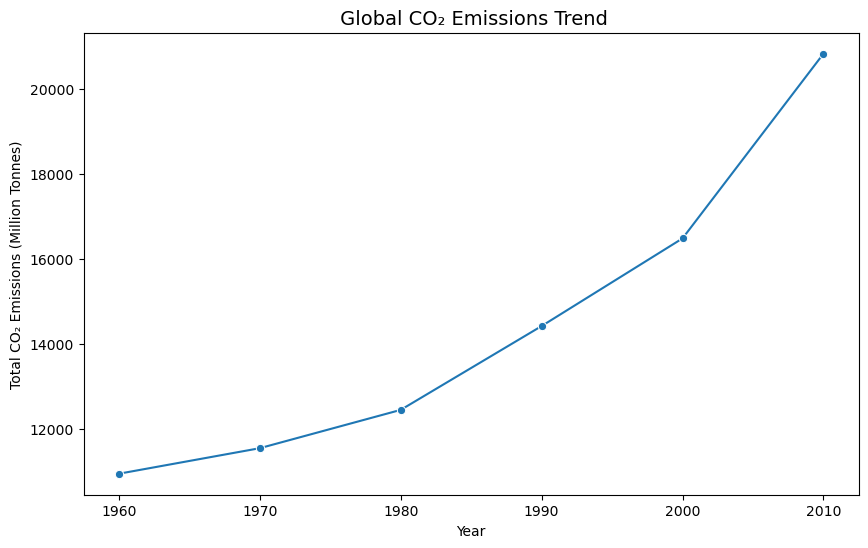

In [22]:
global_trend = df.groupby("year")["co2"].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=global_trend, x="year", y="co2", marker="o")
plt.title(" Global CO₂ Emissions Trend", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total CO₂ Emissions (Million Tonnes)")
plt.savefig("plots/global_trend.png")
plt.show()
plt.close()


## 🔝 Top 10 CO₂ Emitters (Latest Year)
The following bar chart shows the top 10 emitting countries in the most recent year of the dataset.


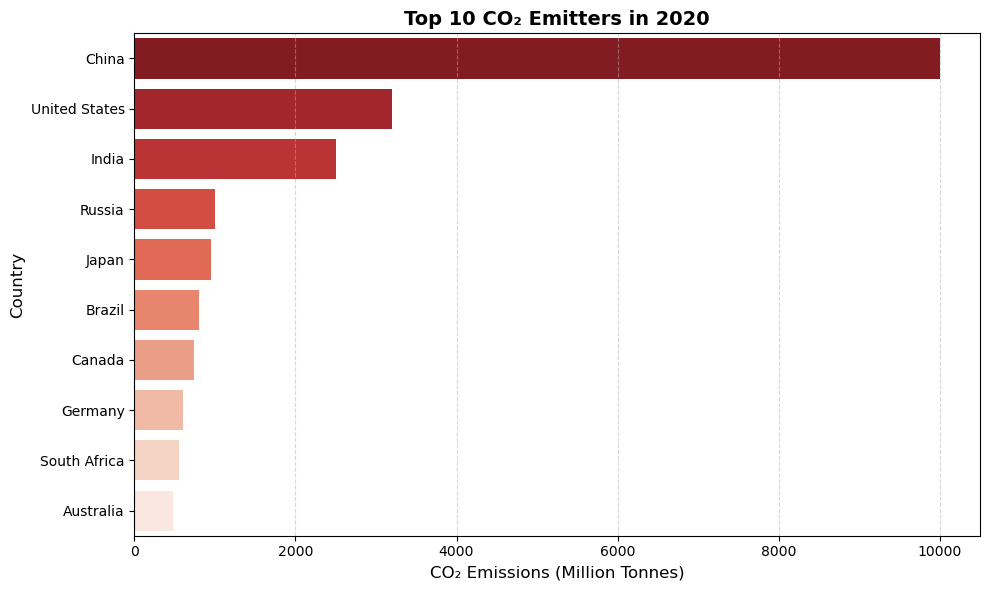

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_emitters, x="co2", y="country", hue="country", palette="Reds_r", legend=False, dodge=False)

plt.title(f"Top 10 CO₂ Emitters in {latest_year}", fontsize=14, fontweight="bold")
plt.xlabel("CO₂ Emissions (Million Tonnes)", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plots/top_emitters.png", bbox_inches="tight")
plt.show()


## 👤 Per Capita CO₂ Emissions
This scatter plot shows emissions per person over time, with colors representing continents.


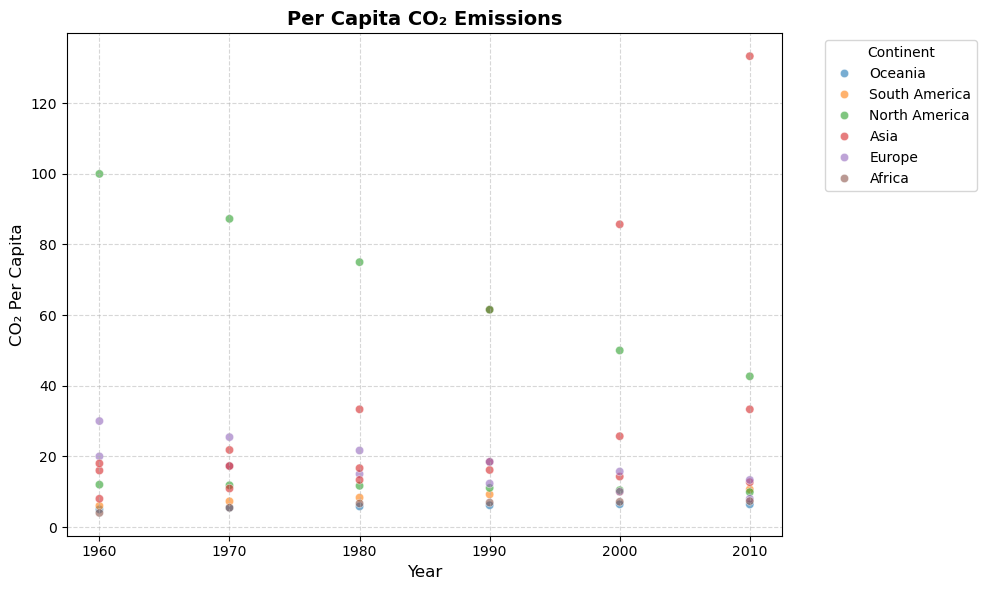

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="year", y="co2_per_capita", hue="continent", alpha=0.6)

plt.title("Per Capita CO₂ Emissions", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ Per Capita", fontsize=12)

plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plots/per_capita.png", bbox_inches="tight")
plt.show()


## 🌍 Continent-wise CO₂ Emissions Trend
This chart compares how emissions from different continents have changed over time.


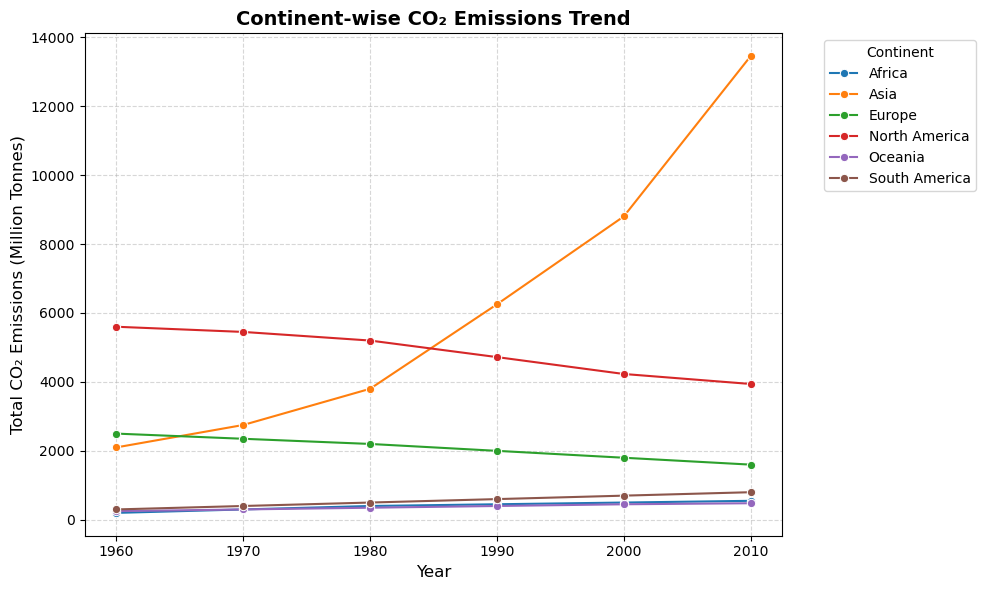

In [43]:
continent_trend = df.groupby(["year", "continent"])["co2"].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=continent_trend, x="year", y="co2", hue="continent", marker="o")

plt.title("Continent-wise CO₂ Emissions Trend", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total CO₂ Emissions (Million Tonnes)", fontsize=12)

plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plots/continent_trend.png", bbox_inches="tight")
plt.show()


## 📈 Top 10 CO₂ Emitters Over Time
This line plot tracks the historical emissions of the top 10 emitting countries, showing shifts in dominance.


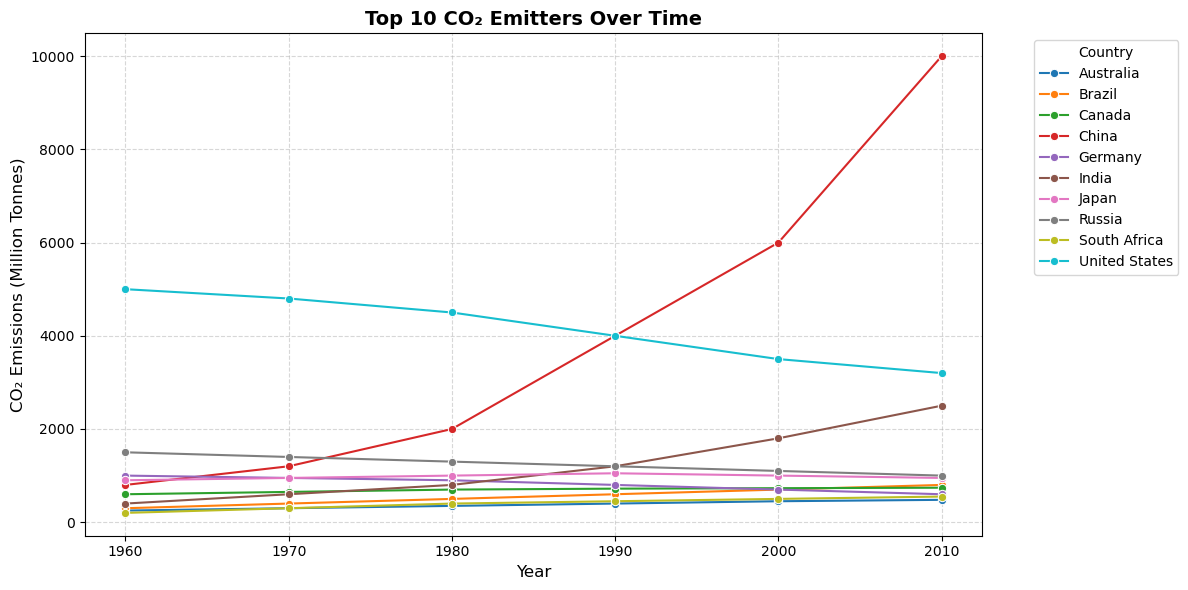

In [44]:
top_countries = df.groupby("country")["co2"].sum().nlargest(10).index
top_over_time = df[df["country"].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=top_over_time, x="year", y="co2", hue="country", marker="o")

plt.title("Top 10 CO₂ Emitters Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ Emissions (Million Tonnes)", fontsize=12)

plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plots/top_emitters_over_time.png", bbox_inches="tight")
plt.show()


## 🔄 CO₂ vs CO₂ Per Capita
This scatter compares total CO₂ emissions against per capita emissions, colored by continent.


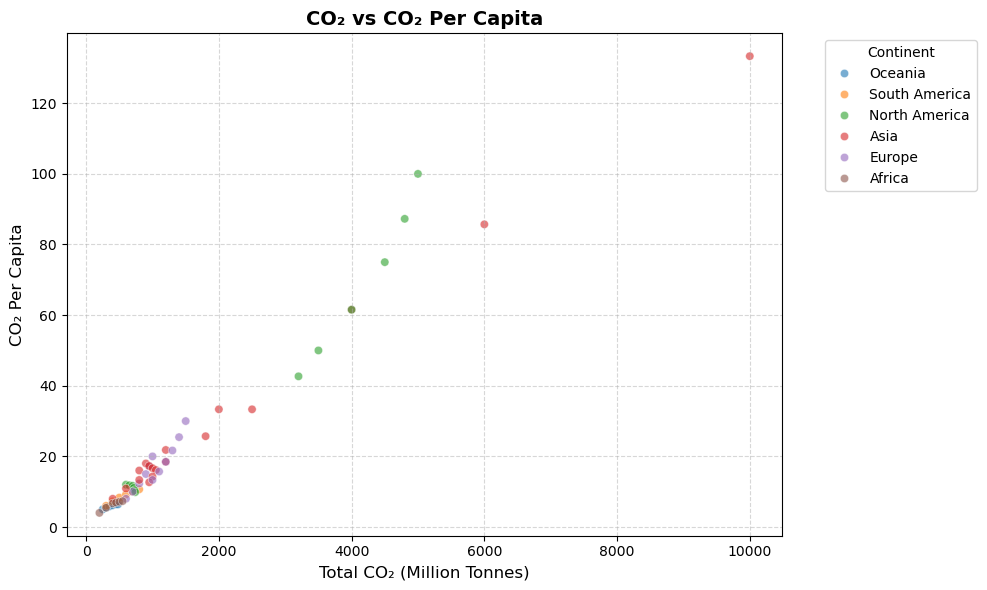

In [45]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="co2", y="co2_per_capita", hue="continent", alpha=0.6)

plt.title("CO₂ vs CO₂ Per Capita", fontsize=14, fontweight="bold")
plt.xlabel("Total CO₂ (Million Tonnes)", fontsize=12)
plt.ylabel("CO₂ Per Capita", fontsize=12)

plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plots/co2_vs_per_capita.png", bbox_inches="tight")
plt.show()


## 📊 Distribution of CO₂ Per Capita
This histogram shows the distribution of per capita emissions across all countries, highlighting inequality.


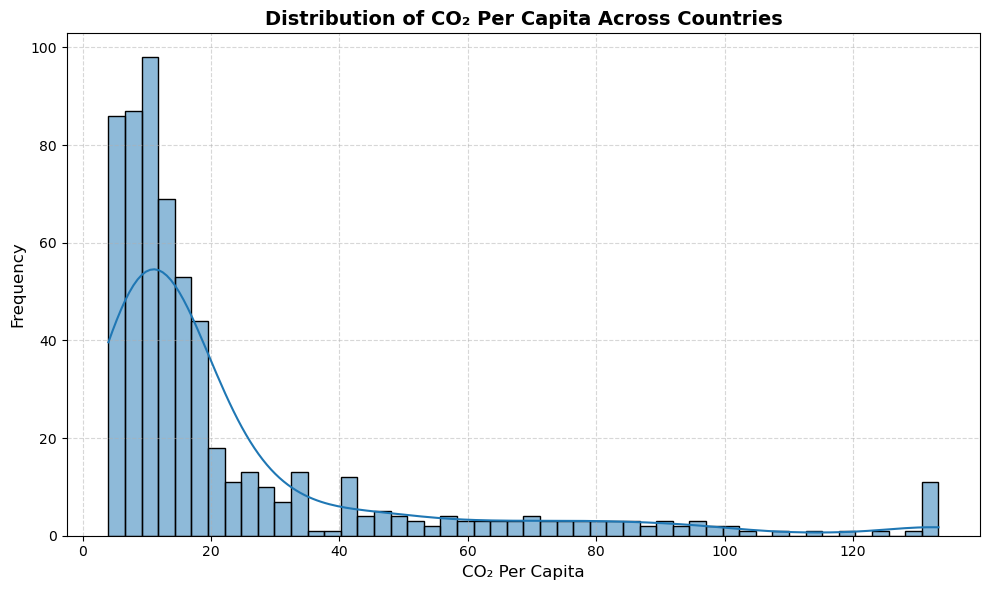

In [46]:
plt.figure(figsize=(10,6))
sns.histplot(df["co2_per_capita"], bins=50, kde=True)

plt.title("Distribution of CO₂ Per Capita Across Countries", fontsize=14, fontweight="bold")
plt.xlabel("CO₂ Per Capita", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plots/per_capita_distribution.png", bbox_inches="tight")
plt.show()


# 🌟 Key Insights from CO₂ Emissions Analysis

1. **Global Trend** 🌍  
   - CO₂ emissions have grown rapidly since the mid-20th century.  
   - The growth curve steepens after the 1950s, highlighting industrialization.  

2. **Top Emitters** 🔝  
   - China, USA, and India remain the dominant contributors.  
   - Europe shows a stable or declining trend.  

3. **Per Capita Emissions** 👤  
   - Developed nations show higher per-person emissions.  
   - Developing economies are lower but rising fast.  

4. **Continental Trends** 🌏  
   - Asia accounts for the largest share, Europe shows a decline.  

5. **Top Emitters Over Time** 📈  
   - Historical dominance by the USA has shifted towards China.  

6. **CO₂ vs Per Capita Scatter** 🔄  
   - Big economies dominate totals; small wealthy nations dominate per capita.  

7. **Distribution of Per Capita Emissions** 📊  
   - Most countries cluster at low values, but a few oil-rich nations form the long tail.  

